# 01 - Découverte Initiale
Dataset d'Activité des Dépôts GitHub - Phase 1 EDA
ENSA Tétouan | ML 2025-2026

**Auteurs:** Ismail LYAMANI, Abdellatif OUMHELLA, Mohammed Aymane SABER

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv('../data/dataset.csv')
print(f'Dimensions : {df.shape}')

Dimensions : (15000, 22)


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   full_name                 15000 non-null  object 
 1   collected_at              15000 non-null  object 
 2   stars                     15000 non-null  int64  
 3   forks                     15000 non-null  int64  
 4   open_issues               15000 non-null  int64  
 5   watchers                  15000 non-null  int64  
 6   size_kb                   15000 non-null  int64  
 7   repo_age_days             15000 non-null  int64  
 8   days_since_last_push      15000 non-null  int64  
 9   contributor_count         15000 non-null  int64  
 10  avg_issue_response_hours  15000 non-null  float64
 11  engagement_rate           15000 non-null  float64
 12  stars_forks_ratio         15000 non-null  float64
 13  language                  15000 non-null  object 
 14  licens

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
stars,15000.0,7.707667,4.424603,4.0000,5.0000,5.0000,14.0000,1.600000e+01
forks,15000.0,3.677600,41.841313,0.0000,0.0000,1.0000,3.0000,4.802000e+03
open_issues,15000.0,4.017067,43.081974,0.0000,0.0000,0.0000,2.0000,4.365000e+03
watchers,15000.0,7.707667,4.424603,4.0000,5.0000,5.0000,14.0000,1.600000e+01
size_kb,15000.0,27360.981667,237035.713632,0.0000,140.0000,721.0000,5529.2500,1.864834e+07
repo_age_days,15000.0,1486.288000,1512.961478,30.0000,191.0000,871.0000,2537.0000,6.656000e+03
days_since_last_push,15000.0,485.152533,1155.611212,0.0000,15.0000,62.0000,138.0000,6.623000e+03
contributor_count,15000.0,5.116600,11.465655,-1.0000,1.0000,2.0000,4.0000,1.000000e+02
avg_issue_response_hours,15000.0,1185.803113,5212.525177,-1.0000,-1.0000,-1.0000,36.0000,1.025754e+05
engagement_rate,15000.0,0.035986,0.083132,0.0007,0.0037,0.0117,0.0391,5.861100e+00


In [4]:
df.head()

,full_name,collected_at,stars,forks,open_issues,watchers,size_kb,repo_age_days,days_since_last_push,contributor_count,...,stars_forks_ratio,language,license,has_description,has_homepage,has_wiki,has_projects,is_fork,archived,is_inactive
0,gsp8181/thai-number-flashcards,2026-05-14T22:01:23.267879+00:00,5,0,0,5,135,156,147,2,...,5.00,JavaScript,MIT License,0,0,0,1,0,0,0
1,openMF/mifos-workflow,2026-05-15T02:03:38.911022+00:00,5,9,9,5,1149,367,2,4,...,0.56,Java,Mozilla Public License 2.0,0,0,1,1,0,0,0
2,Obsidian-OS/installer,2026-05-15T02:33:24.080292+00:00,5,0,1,5,165,268,112,2,...,5.00,C++,MIT License,1,0,0,0,0,0,0
3,enovella/bhd-ebook-exercises,2026-05-14T20:57:03.965027+00:00,5,2,0,5,36235,3188,2676,1,...,2.50,C,NaN,1,0,1,1,0,0,1
4,makoConstruct/jostletree.rs,2026-05-14T20:39:11.957857+00:00,5,0,1,5,51,4258,375,2,...,5.00,Rust,NaN,1,0,1,1,0,0,1


## Distribution des classes (vérification du déséquilibre)

In [5]:
counts = df['is_inactive'].value_counts().sort_index()
labels = ['Actif (0)', 'Inactif (1)']
pct = counts / len(df) * 100

print('=== Distribution des classes ===')
for cls, cnt, p in zip(labels, counts, pct):
    print(f'  {cls}: {cnt:>6}  ({p:.1f}%)')
minority_pct = pct.iloc[1]
status = 'VALID' if 5 <= minority_pct <= 25 else 'WARNING'
print(f'\nRatio de la classe minoritaire : {minority_pct:.1f}%  [{status}]')

=== Distribution des classes ===
  Actif (0):  12750  (85.0%)
  Inactif (1):   2250  (15.0%)

Ratio de la classe minoritaire : 15.0%  [VALID]


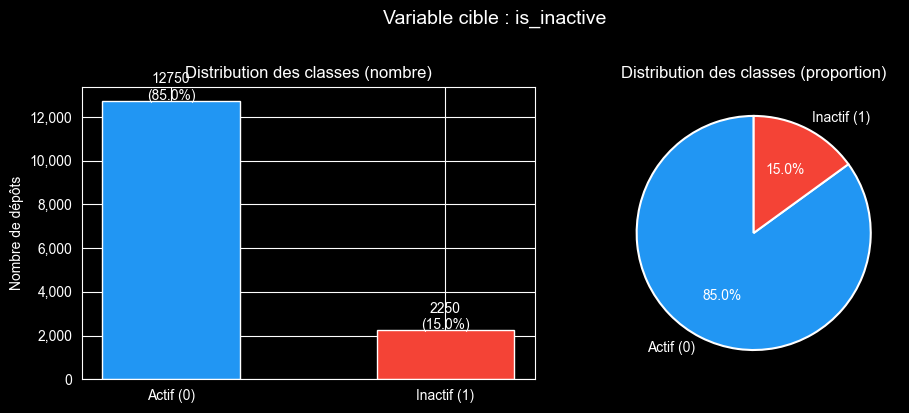

Sauvegardé dans data/class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2196F3', '#F44336']
axes[0].bar(labels, counts.values, color=colors, width=0.5)
for i, (cnt, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, cnt + 50, f'{cnt}\n({p:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribution des classes (nombre)', fontsize=12)
axes[0].set_ylabel('Nombre de dépôts')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
axes[1].set_title('Distribution des classes (proportion)', fontsize=12)
plt.suptitle('Variable cible : is_inactive', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé dans data/class_distribution.png')

## Valeurs manquantes

In [7]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
license,5200,34.67


## Distributions des caractéristiques (toutes les colonnes numériques)

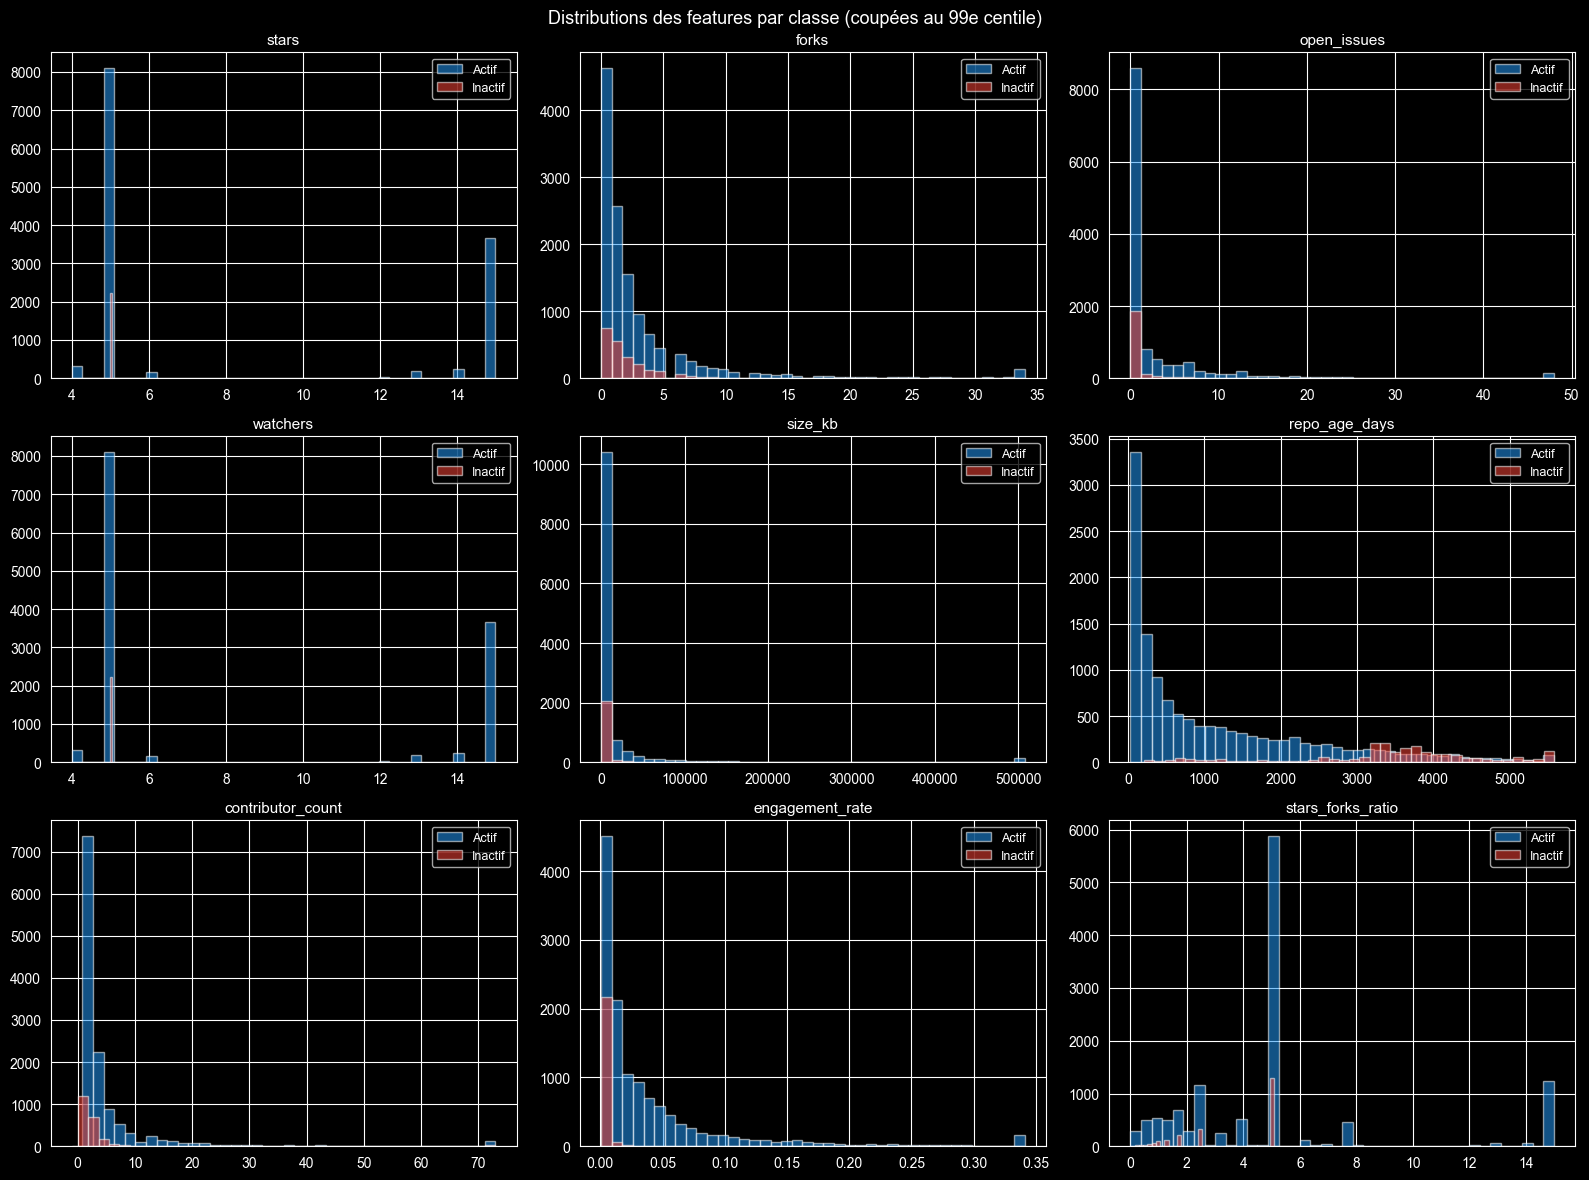

In [8]:
numeric_cols = [
    'stars', 'forks', 'open_issues', 'watchers', 'size_kb',
    'repo_age_days', 'contributor_count', 'engagement_rate',
    'stars_forks_ratio', 'avg_issue_response_hours'
]
plot_cols = [c for c in numeric_cols if c != 'avg_issue_response_hours']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    for cls, clr, lbl in [(0, '#2196F3', 'Actif'), (1, '#F44336', 'Inactif')]:
        subset = df[df['is_inactive'] == cls][col].astype(float).clip(upper=df[col].quantile(0.99))
        axes[i].hist(subset, bins=40, alpha=0.55, color=clr, label=lbl)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=9)
plt.suptitle('Distributions des features par classe (coupées au 99e centile)', fontsize=13)
plt.tight_layout()
plt.show()

Dépôts sans issues fermées (sentinelle -1.0) : 68.3%


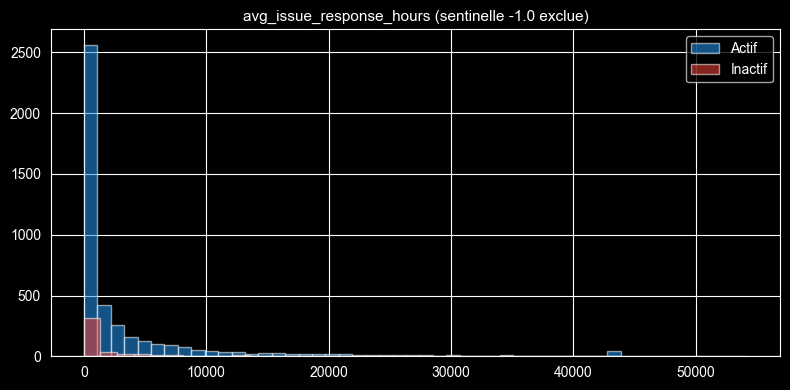

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, clr, lbl in [(0, '#2196F3', 'Actif'), (1, '#F44336', 'Inactif')]:
    subset = df[(df['is_inactive'] == cls) & (df['avg_issue_response_hours'] >= 0)]['avg_issue_response_hours']
    subset = subset.astype(float).clip(upper=subset.quantile(0.99))
    ax.hist(subset, bins=40, alpha=0.55, color=clr, label=lbl)
ax.set_title('avg_issue_response_hours (sentinelle -1.0 exclue)', fontsize=11)
ax.legend()
pct_sentinel = (df['avg_issue_response_hours'] == -1.0).mean() * 100
print(f'Dépôts sans issues fermées (sentinelle -1.0) : {pct_sentinel:.1f}%')
plt.tight_layout()
plt.show()

## Distributions catégorielles

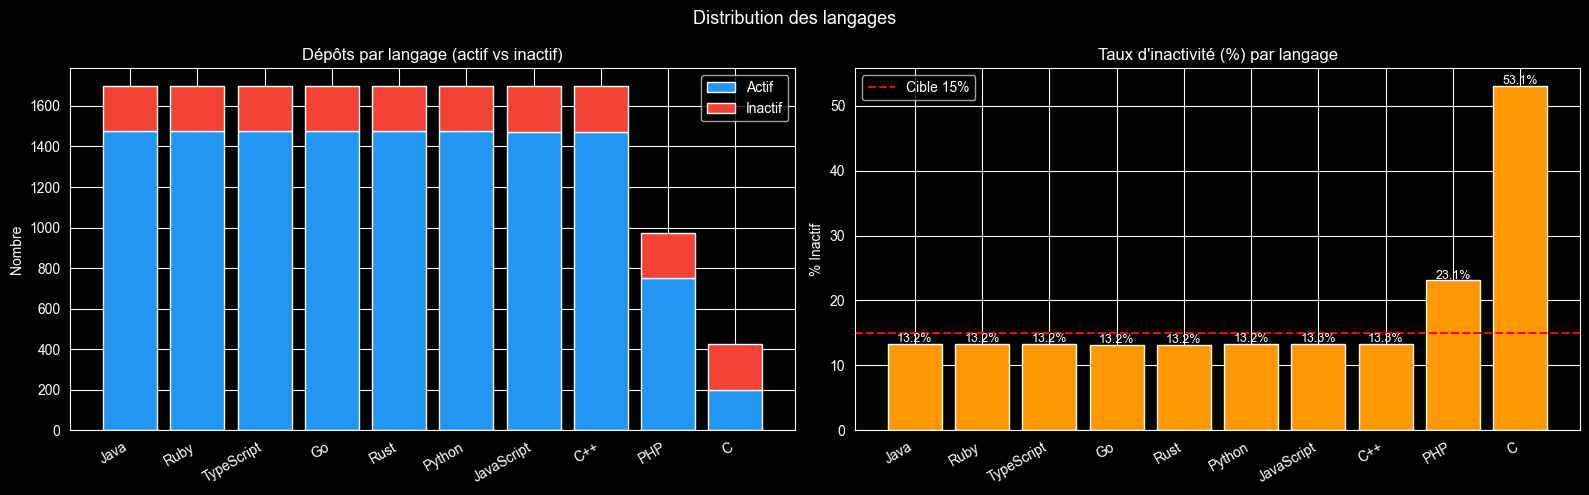

Sauvegardé → data/language_distribution.png


In [10]:
# --- Distribution des langages (nombre + taux d'inactifs par langage) ---
lang_counts = df['language'].value_counts().head(10)
lang_inactive = df[df['is_inactive'] == 1]['language'].value_counts()
lang_active = df[df['is_inactive'] == 0]['language'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: stacked bar active vs inactive per language
langs = lang_counts.index.tolist()
active_vals = [lang_active.get(l, 0) for l in langs]
inactive_vals = [lang_inactive.get(l, 0) for l in langs]
x = range(len(langs))
axes[0].bar(x, active_vals, label='Actif', color='#2196F3')
axes[0].bar(x, inactive_vals, bottom=active_vals, label='Inactif', color='#F44336')
axes[0].set_xticks(x)
axes[0].set_xticklabels(langs, rotation=30, ha='right')
axes[0].set_title('Dépôts par langage (actif vs inactif)', fontsize=12)
axes[0].set_ylabel('Nombre')
axes[0].legend()

# Right: inactive rate per language
inactive_rate = [(lang_inactive.get(l, 0) / lang_counts[l] * 100) for l in langs]
bars = axes[1].bar(x, inactive_rate, color='#FF9800')
axes[1].set_xticks(x)
axes[1].set_xticklabels(langs, rotation=30, ha='right')
axes[1].axhline(15, color='red', linestyle='--', label='Cible 15%')
axes[1].set_title('Taux d\'inactivité (%) par langage', fontsize=12)
axes[1].set_ylabel('% Inactif')
axes[1].legend()
for bar, val in zip(bars, inactive_rate):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Distribution des langages', fontsize=13)
plt.tight_layout()
plt.savefig('../data/language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → data/language_distribution.png')

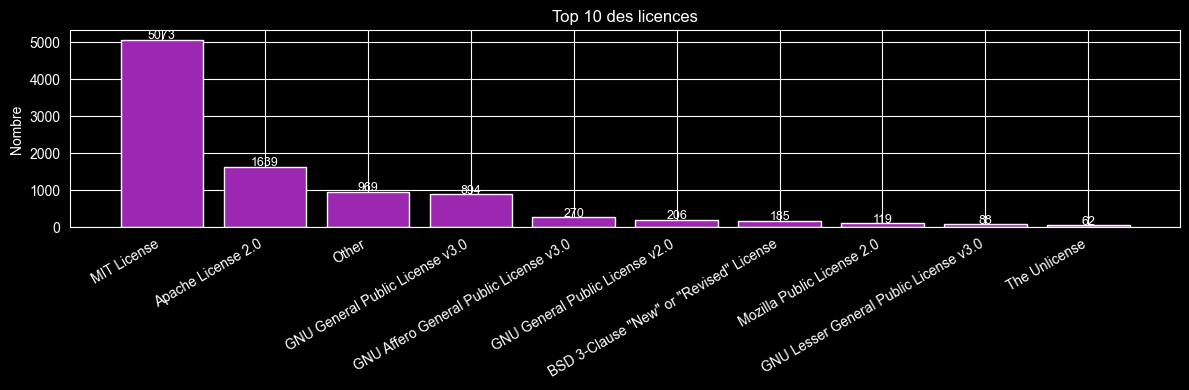

--- Décompte des langages ---
language
Java          1700
Ruby          1700
TypeScript    1700
Go            1699
Rust          1699
Python        1699
JavaScript    1698
C++           1698
PHP            975
C              424
Name: count, dtype: int64

--- Décompte des licences ---
license
MIT License                                5073
Apache License 2.0                         1639
Other                                       969
GNU General Public License v3.0             894
GNU Affero General Public License v3.0      270
GNU General Public License v2.0             206
BSD 3-Clause "New" or "Revised" License     185
Mozilla Public License 2.0                  119
GNU Lesser General Public License v3.0       88
The Unlicense                                62
Name: count, dtype: int64


In [11]:
# --- Distribution des licences ---
fig, ax = plt.subplots(figsize=(12, 4))
lic_counts = df['license'].value_counts().head(10)
x = range(len(lic_counts))
bars = ax.bar(x, lic_counts.values, color='#9C27B0')
ax.set_title('Top 10 des licences', fontsize=12)
ax.set_ylabel('Nombre')
ax.set_xticks(x)
ax.set_xticklabels(lic_counts.index, rotation=30, ha='right')
for bar, val in zip(bars, lic_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('--- Décompte des langages ---')
print(df['language'].value_counts().head(10))
print('\n--- Décompte des licences ---')
print(df['license'].value_counts().head(10))

## Carte thermique des corrélations (Heatmap)

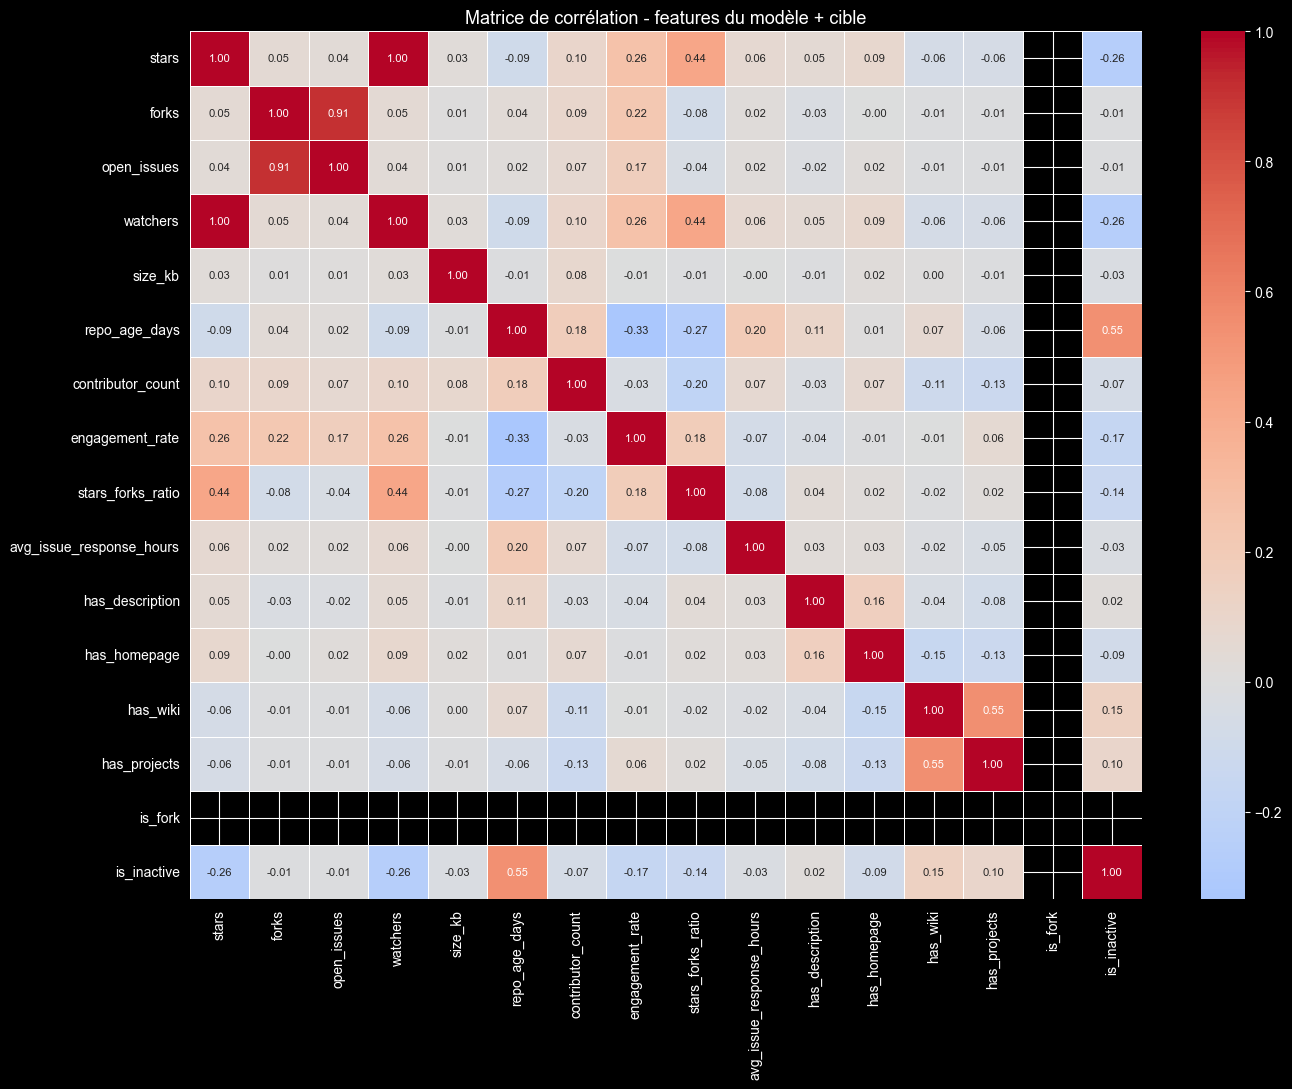

Sauvegardé dans data/correlation_matrix.png

Top des corrélations avec is_inactive :
repo_age_days               0.545984
stars                      -0.256955
watchers                   -0.256955
engagement_rate            -0.166312
has_wiki                    0.146573
stars_forks_ratio          -0.139993
has_projects                0.102848
has_homepage               -0.088025
contributor_count          -0.066039
avg_issue_response_hours   -0.029325
size_kb                    -0.028239
has_description             0.020774
open_issues                -0.014165
forks                      -0.006924
is_fork                          NaN


In [12]:
model_cols = [
    'stars', 'forks', 'open_issues', 'watchers', 'size_kb',
    'repo_age_days', 'contributor_count', 'engagement_rate',
    'stars_forks_ratio', 'avg_issue_response_hours',
    'has_description', 'has_homepage', 'has_wiki', 'has_projects', 'is_fork',
    'is_inactive'
]
corr = df[model_cols].corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation - features du modèle + cible', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé dans data/correlation_matrix.png')
print('\nTop des corrélations avec is_inactive :')
print(corr['is_inactive'].drop('is_inactive').sort_values(key=abs, ascending=False).to_string())

## Vérification des avertissements de fuite de données (Leakage)

In [13]:
print('Colonnes à SUPPRIMER avant la modélisation (fuite de données / leakage) :')
print('  - days_since_last_push  (encode directement l\'étiquette)')
print('  - archived              (étiquette post-hoc, pas une feature prédictive)')
print('  - full_name             (identifiant)')
print('  - collected_at          (identifiant)')
print()
print('Toutes les autres colonnes peuvent être utilisées comme features en toute sécurité.')

Colonnes à SUPPRIMER avant la modélisation (fuite de données / leakage) :
  - days_since_last_push  (encode directement l'étiquette)
  - archived              (étiquette post-hoc, pas une feature prédictive)
  - full_name             (identifiant)
  - collected_at          (identifiant)

Toutes les autres colonnes peuvent être utilisées comme features en toute sécurité.
